In [1]:
import os
os.chdir('../../../../..')

In [2]:
import polars as pl
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from kmedoids import KMedoids
from hdbscan import HDBSCAN

from src.helper_functions import create_chemiscope_viewer, average_numeric_by_cluster, plot_distance_matrix_projection
from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, Wasserstein

INFO: Enabling RDKit 2025.09.4 jupyter extensions


In [3]:
qm9 = QM9Dataset(limit=1500, descriptors=["mace"], sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()

2026-04-27 16:27:04.425 | INFO     | src.datasets:load:864 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-27 16:27:04.855 | INFO     | src.datasets:_sample_qm9_df:1064 - QM9 sampling complete: strategy=stratified, requested_limit=1651, returned_rows=1651.
2026-04-27 16:27:04.856 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=1651).
2026-04-27 16:27:04.856 | INFO     | src.features:compute_mace_outputs:654 - Computing MACE embeddings (model=medium, batch_size=32)...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using MACE-OFF23 MODEL for MACECalculator with /Users/karlfindhansen/.cache/mace/MACE-OFF23_medium.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


2026-04-27 16:29:00.931 | SUCCESS  | src.datasets:add_mace:1268 - Added MACE embeddings and matrices.
2026-04-27 16:29:00.932 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['mace_embedding', 'mace_matrix']
2026-04-27 16:29:00.941 | INFO     | src.datasets:load:903 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=1500, returned_rows=1500, base_rows=1651.


# Riemann

In [4]:
riemann = Riemann()
dist_matrix_riemann = riemann.distance_matrix(df=df, descriptor='mace')

2026-04-27 16:29:00.956 | INFO     | src.non_euclidean:_load_cached_distance_matrix:286 - Loading cached riemann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/riemann_n1500_mace_affine-invariant_nopca.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_37320/3592406822.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_riemann, method='complete')


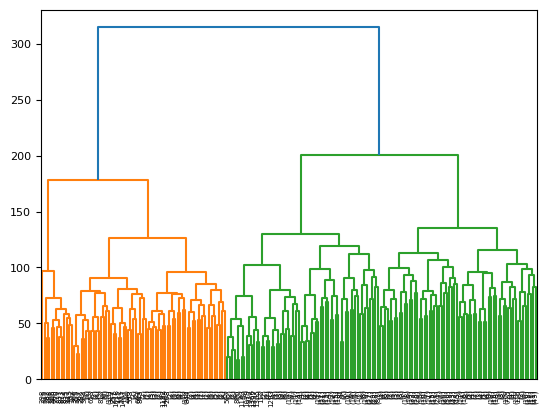

In [5]:
Z = linkage(dist_matrix_riemann, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=7, 
)

In [6]:
model_hier_riemann = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='complete')
labels_hier_riemann = model_hier_riemann.fit_predict(dist_matrix_riemann)
print(np.unique(labels_hier_riemann, return_counts=True))
df = df.with_columns(labels_hier_riemann=labels_hier_riemann)

(array([0, 1, 2]), array([1428,    6,   66]))


In [7]:
create_chemiscope_viewer(df, dist_matrix_riemann, labels_hier_riemann, 'MDS')

2026-04-27 16:29:01.777 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running MDS dimensionality reduction...
2026-04-27 16:29:01.778 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:29:27.979 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [8]:
average_numeric_by_cluster(df, "labels_hier_riemann")

shape: (3, 71)
┌─────────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier_riemann,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1428,2.060157,0.0,122.466387,0.134454,35.987395,0.878058,12.83861,8.753501,1.546919,0.114146,0.008403,2.332633,18.578431,2.050791,2.440476,0.071084,0.203988,0.724928,0.906162,1.972689,6.495098,0.465686,1.191176,4.764006,6.380952,38.589636,1.260815,0.001401,0.37465,0.031513,0.12395,0.12535,0.0007,0.036415,0.126751,0.534314,0.0,2.647652,75.513536,-6.555831,0.373876,6.929709,1206.617459,4.15318,-11100.973411,-11100.738219,-11100.712529,-11101.888857,32.08918,-77.143203,-77.614326,-78.059653,-71.790997,3.438,1.376568,1.109841,76.330532,11.134454,12.535014,38.589636,553,"""Acyclic""",12.535014,190,"""C1CCCC1""",12.885154,1,null,0.0
1,6,2.041722,0.0,126.5,-0.5,47.166667,0.900242,12.84012,9.0,3.0,0.0,0.0,3.333333,16.166667,2.125014,2.333333,0.033333,0.234921,0.731746,0.833333,2.833333,6.166667,0.166667,1.333333,4.166667,6.5,33.166667,1.274318,0.0,0.0,0.0,0.0,0.166667,0.0,0.0,0.666667,0.833333,0.0,3.5552,70.52,-7.055912,-0.727451,6.328461,1193.417623,3.112121,-12239.247559,-12239.024577,-12238.999023,-12240.157715,29.762499,-65.744956,-66.113066,-66.481413,-61.217571,3.368323,1.208353,0.999802,100.0,0.0,0.0,33.166667,4,"""O=C1C2CC1O2""",50.0,2,"""CC1C2CC1C2""",66.666667,1,null,0.0
2,66,2.163153,0.0,120.060606,-0.30303,17.893939,0.903722,12.702333,8.818182,3.242424,0.0,0.0,1.545455,18.333333,2.223813,1.318182,0.100998,0.058381,0.84062,0.878788,1.0,7.19697,0.742424,0.393939,6.136364,6.181818,39.818182,1.280399,0.0,0.212121,0.0,0.060606,0.015152,0.0,0.0,0.060606,0.484848,0.0,1.985245,76.550909,-6.339346,0.754704,7.094132,1038.668599,3.925512,-10436.246575,-10436.04214,-10436.016513,-10437.113533,29.666152,-75.25516,-75.729419,-76.156221,-70.065557,3.662896,1.594495,1.351428,100.0,0.0,0.0,39.818182,41,"""C1C2C[NH+]3C1C23""",7.575758,27,"""C1C2CC3C1C23""",13.636364,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


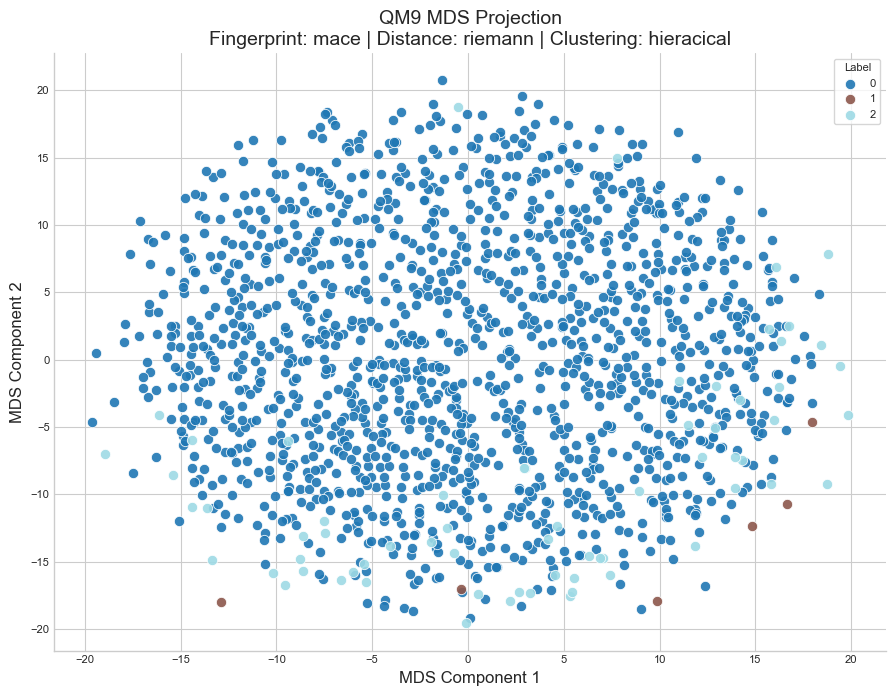

2026-04-27 16:29:48.009 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/qm9/clustering/riemann/mace/mds_hieracical_projection.png


In [9]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_riemann,
    fingerprint="mace",
    distance_metric="riemann",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_riemann,
    clustering_method="hieracical"
)

# Grassmann

In [10]:
grassmann = Grassmann()
dist_matrix_grass = grassmann.distance_matrix(df=df, descriptor='mace')

2026-04-27 16:29:48.027 | INFO     | src.non_euclidean:_load_cached_distance_matrix:286 - Loading cached grassmann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/grassmann_n1500_mace_k3_svd_norm.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_37320/3709222914.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_grass, method='complete')


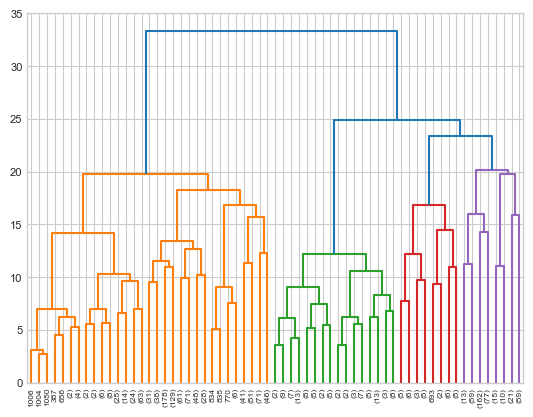

In [11]:
Z = linkage(dist_matrix_grass, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [12]:
model_hier_grass = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_grass = model_hier_grass.fit_predict(dist_matrix_grass)
print(np.unique(labels_hier_grass, return_counts=True))
df = df.with_columns(labels_hier_grass=labels_hier_grass)

(array([0, 1, 2, 3]), array([597, 215, 596,  92]))


In [23]:
create_chemiscope_viewer(df, dist_matrix_grass, labels_hier_grass, 'MDS')

2026-04-27 16:41:42.199 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running MDS dimensionality reduction...
2026-04-27 16:41:42.200 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:42:04.306 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [14]:
average_numeric_by_cluster(df, "labels_hier_grass")

shape: (4, 72)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬─

labels_hier_grass,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier_riemann,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,597,2.088256,0.0,122.747069,0.021776,39.850921,0.835083,12.884558,8.745394,1.554439,0.060302,0.015075,2.549414,18.656616,2.05382,2.532663,0.059072,0.147105,0.793823,0.958124,2.067002,6.512563,0.348409,0.865997,4.981575,6.264657,39.165829,1.261256,0.0,0.333333,0.00335,0.147404,0.19598,0.0,0.046901,0.097152,0.530988,0.0,3.006236,74.391256,-6.702401,0.457042,7.159525,1194.947487,4.145423,-11149.803201,-11149.567761,-11149.542044,-11150.719467,31.977099,-76.639027,-77.108415,-77.552759,-71.296533,3.365074,1.368503,1.113519,0.090452,79.229481,6.030151,14.740369,39.165829,277,"""Acyclic""",14.740369,116,"""Acyclic""",14.740369,1,null,0.0
1,215,2.189544,0.0,123.544186,0.218605,24.004651,0.955185,12.813443,8.767442,2.423256,0.0,0.0,1.706977,20.739535,2.124578,2.655814,0.0,0.002326,0.997674,1.004651,1.539535,7.293023,0.0,0.013953,7.046512,6.274419,45.483721,1.265779,0.0,0.767442,0.0,0.009302,0.0,0.0,0.0,0.0,0.688372,0.0,1.586635,77.608651,-6.458262,1.89995,8.358237,1140.823932,4.863854,-10872.393169,-10872.1622,-10872.136537,-10873.289755,32.98954,-83.805827,-84.366293,-84.868412,-77.801391,3.113584,1.496132,1.264033,0.130233,96.27907,0.0,3.72093,45.483721,124,"""C1CC2CC12""",6.511628,70,"""C1CC2CC12""",12.55814,1,null,0.0
2,596,2.034494,0.0,121.714765,0.171141,31.823826,0.914521,12.776511,8.771812,1.489933,0.092282,0.001678,2.110738,18.129195,2.046309,2.145973,0.110586,0.24957,0.639844,0.721477,1.786913,6.360738,0.780201,1.526846,4.354027,6.516779,37.139262,1.261867,0.001678,0.248322,0.02349,0.092282,0.095638,0.001678,0.040268,0.213087,0.515101,0.0,2.613407,76.484262,-6.526856,-0.150032,6.376751,1232.565811,4.000913,-10996.112487,-10995.877731,-10995.852047,-10997.031256,31.882554,-76.341694,-76.796301,-77.230301,-71.121447,3.593203,1.354673,1.082252,0.09396,77.684564,9.228188,13.087248,37.139262,271,"""Acyclic""",13.087248,109,"""C1CC1""",15.268456,1,null,0.0
3,92,1.814386,0.0,121.532609,0.076087,53.641304,0.760328,12.903892,8.717391,1.130435,0.782609,0.021739,3.326087,15.597826,2.016696,2.434783,0.078235,0.646661,0.275104,1.51087,2.934783,5.869565,0.456522,3.315217,1.619565,6.369565,28.663043,1.254467,0.01087,0.402174,0.315217,0.391304,0.076087,0.0,0.0,0.043478,0.304348,0.0,2.606141,72.029891,-5.897742,-0.136767,5.760946,1146.655941,3.297901,-11594.975055,-11594.751645,-11594.726085,-11595.872601,30.160967,-67.939154,-68.315281,-68.689328,-63.36374,3.820729,1.436697,1.070502,0.0,20.652174,73.913043,5.434783,28.663043,38,"""c1cc[nH]c1""",14.130435,16,"""C1CCCC1""",59.782609,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


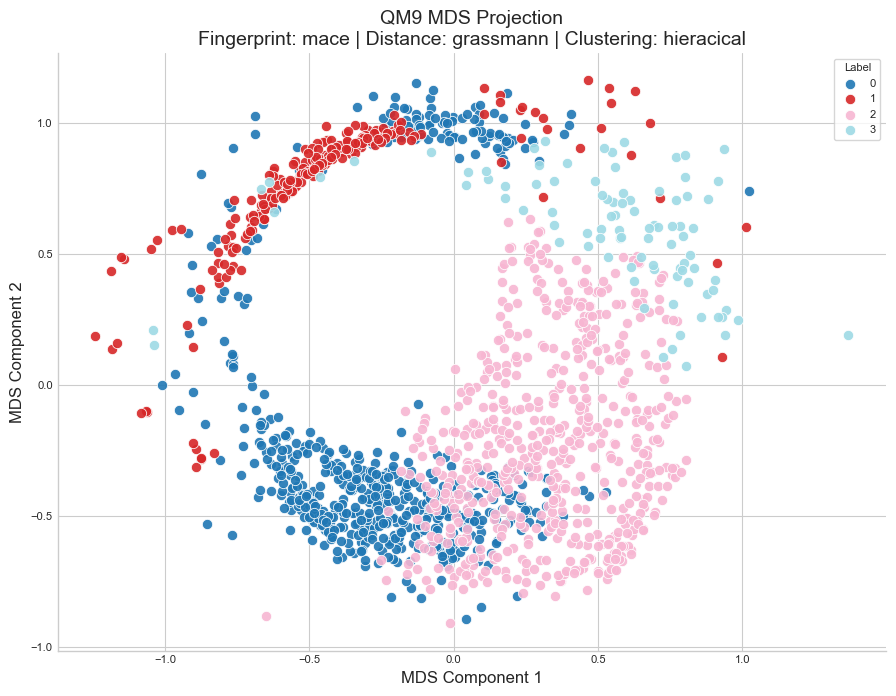

2026-04-27 16:30:21.498 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/qm9/clustering/grassmann/mace/mds_hieracical_projection.png


In [15]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_grass,
    fingerprint="mace",
    distance_metric="grassmann",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_grass,
    clustering_method="hieracical"
)

# Wasserstein

In [16]:
wasserstein = Wasserstein()
dist_matrix_wasser = wasserstein.distance_matrix(df=df, descriptor='mace')

2026-04-27 16:30:21.535 | INFO     | src.non_euclidean:_load_cached_distance_matrix:286 - Loading cached wasserstein distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/wasserstein_n1500_mace_sqeuclidean.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_37320/1791206022.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_wasser, method='complete')


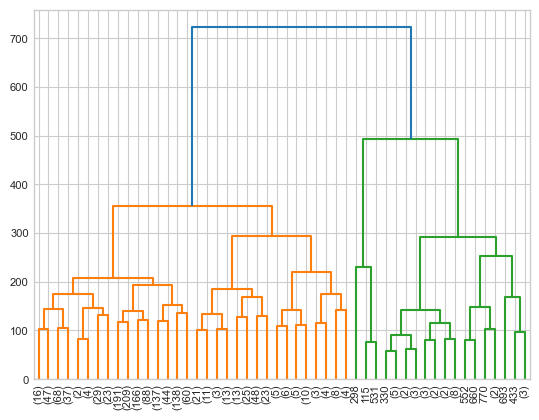

In [17]:
Z = linkage(dist_matrix_wasser, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [26]:
model_hier_wasser = AgglomerativeClustering(metric='precomputed', n_clusters=2, linkage='complete')
labels_hier_wasser = model_hier_wasser.fit_predict(dist_matrix_wasser)
print(np.unique(labels_hier_wasser, return_counts=True))
df = df.with_columns(labels_hier_wasser=labels_hier_wasser)

(array([0, 1]), array([1309,  191]))


In [30]:
create_chemiscope_viewer(df, dist_matrix_wasser, labels_hier_wasser, 'MDS')

2026-04-27 16:47:05.247 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running MDS dimensionality reduction...
2026-04-27 16:47:05.247 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-27 16:47:38.983 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [20]:
average_numeric_by_cluster(df, "labels_hier_wasser")

shape: (4, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬───────────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_hier_wasser,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier_riemann,labels_hier_grass,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,182,1.985537,0.0,123.434066,-0.406593,55.208791,0.846488,12.884118,8.769231,1.5,0.043956,0.0,3.357143,16.115385,2.053192,2.032967,0.114914,0.194375,0.690712,1.203297,2.813187,5.472527,0.653846,1.005495,3.752747,6.142857,32.076923,1.269256,0.0,0.461538,0.005495,0.197802,0.225275,0.0,0.098901,0.252747,0.681319,0.0,3.384962,67.969945,-6.91987,-0.429686,6.490274,1129.022263,3.299024,-11875.984037,-11875.76035,-11875.734584,-11876.891199,29.960896,-67.680582,-68.060398,-68.437143,-63.079253,3.432801,1.400635,1.123411,0.032967,0.945055,79.120879,4.395604,16.483516,32.076923,102,"""Acyclic""",16.483516,51,"""Acyclic""",16.483516,1,null,0.0
1,1087,2.12235,0.0,122.74517,0.192272,28.931923,0.913383,12.814586,8.774609,1.762649,0.00184,0.00828,1.952162,19.605336,2.071544,2.50322,0.061395,0.108689,0.829916,0.809568,1.643974,6.821527,0.432383,0.724011,5.666053,6.397424,41.731371,1.261841,0.0,0.401104,0.0,0.069917,0.094756,0.00092,0.023919,0.106716,0.579577,0.0,2.392945,77.35874,-6.573207,0.703223,7.276417,1213.10651,4.466701,-10905.082947,-10904.845028,-10904.819346,-10905.999055,32.814248,-80.485225,-80.992421,-81.463633,-74.844441,3.235592,1.384902,1.139373,0.119595,1.018399,89.144434,0.183993,10.671573,41.731371,451,"""Acyclic""",10.671573,174,"""C1CC1""",13.799448,1,null,0.0
2,222,1.843601,0.0,119.612613,0.18018,49.752252,0.739446,12.877883,8.657658,0.972973,0.689189,0.013514,3.13964,15.427928,1.995356,2.148649,0.092594,0.642273,0.265133,1.099099,2.621622,5.90991,0.563063,3.432432,1.522523,6.45045,28.707207,1.254829,0.009009,0.099099,0.198198,0.306306,0.162162,0.0,0.036036,0.121622,0.18018,0.0,3.153279,72.888334,-6.129598,-0.539374,5.590236,1193.226651,3.223146,-11246.237661,-11246.015051,-11245.989407,-11247.143484,29.54482,-67.753683,-68.120374,-68.487581,-63.271694,4.49886,1.371387,1.018433,0.009009,1.806306,18.018018,67.117117,14.864865,28.707207,80,"""Acyclic""",14.864865,21,"""C1CCCC1""",46.846847,1,null,0.0
3,9,2.142409,0.0,124.666667,-0.666667,34.666667,0.872106,12.85283,8.888889,4.0,0.0,0.0,2.555556,18.666667,2.181455,2.0,0.018519,0.050265,0.931217,1.555556,2.111111,7.111111,0.111111,0.333333,5.888889,6.111111,40.0,1.2664,0.0,0.777778,0.0,0.111111,0.111111,0.0,0.0,0.0,0.666667,0.0,1.775889,74.235557,-6.355068,1.431319,7.786689,1081.913384,4.136959,-11388.752387,-11388.537218,-11388.511502,-11389.633572,30.996667,-75.020031,-75.511238,-75.956744,-69.614258,3.424528,1.497154,1.221594,0.0,0.333333,100.0,0.0,0.0,40.0,8,"""C1C2CC1N2""",22.222222,6,"""C1C2CC1C2""",44.444444,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


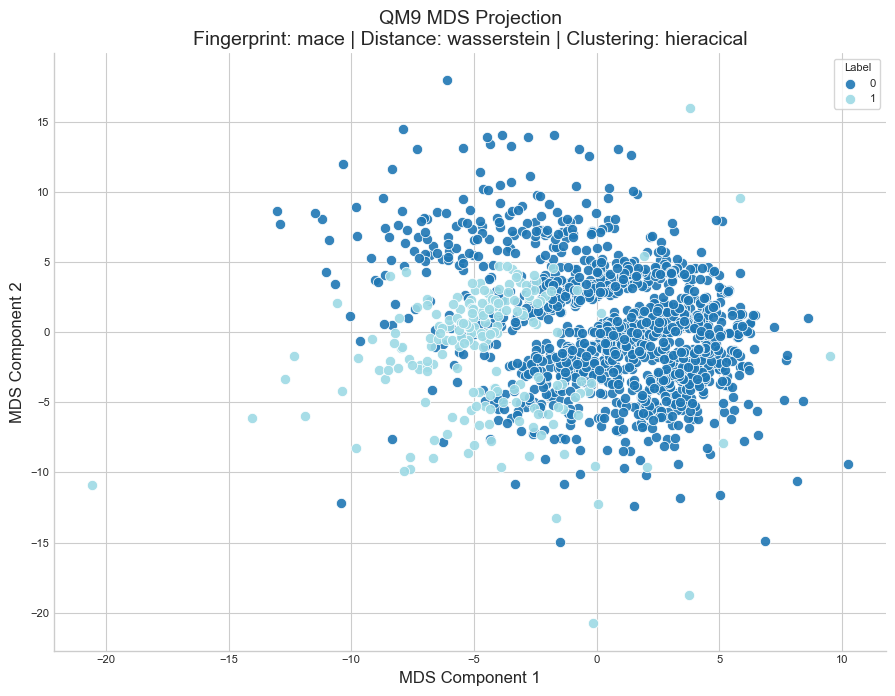

2026-04-27 16:48:03.512 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/qm9/clustering/wasserstein/mace/mds_hieracical_projection.png


In [31]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_wasser,
    fingerprint="mace",
    distance_metric="wasserstein",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_wasser,
    clustering_method="hieracical"
)